In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

# Ładowanie danych

In [2]:
import tensorflow_datasets as tfds
[test_set_raw, valid_set_raw, train_set_raw], info = tfds.load("tf_flowers",
                                                               split=['train[:10%]', "train[10%:25%]", "train[25%:]"],
                                                               as_supervised=True,
                                                               with_info=True)

2025-06-02 12:17:02.964779: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2025-06-02 12:17:02.964801: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 48.00 GB
2025-06-02 12:17:02.964806: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 18.00 GB
I0000 00:00:1748859422.964820 3024982 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1748859422.964838 3024982 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [3]:
class_names = info.features["label"].names
n_classes = info.features["label"].num_classes
dataset_size = info.splits["train"].num_examples

In [4]:
info

tfds.core.DatasetInfo(
    name='tf_flowers',
    full_name='tf_flowers/3.0.1',
    description="""
    A large set of images of flowers
    """,
    homepage='https://www.tensorflow.org/tutorials/load_data/images',
    data_dir='/Users/maciek/tensorflow_datasets/tf_flowers/3.0.1',
    file_format=tfrecord,
    download_size=218.21 MiB,
    dataset_size=221.83 MiB,
    features=FeaturesDict({
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=5),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'train': <SplitInfo num_examples=3670, num_shards=2>,
    },
    citation="""@ONLINE {tfflowers,
    author = "The TensorFlow Team",
    title = "Flowers",
    month = "jan",
    year = "2019",
    url = "http://download.tensorflow.org/example_images/flower_photos.tgz" }""",
)

2025-06-02 12:17:03.043627: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:387] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608
2025-06-02 12:17:03.070899: W tensorflow/core/kernels/data/cache_dataset_ops.cc:916] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2025-06-02 12:17:03.073013: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


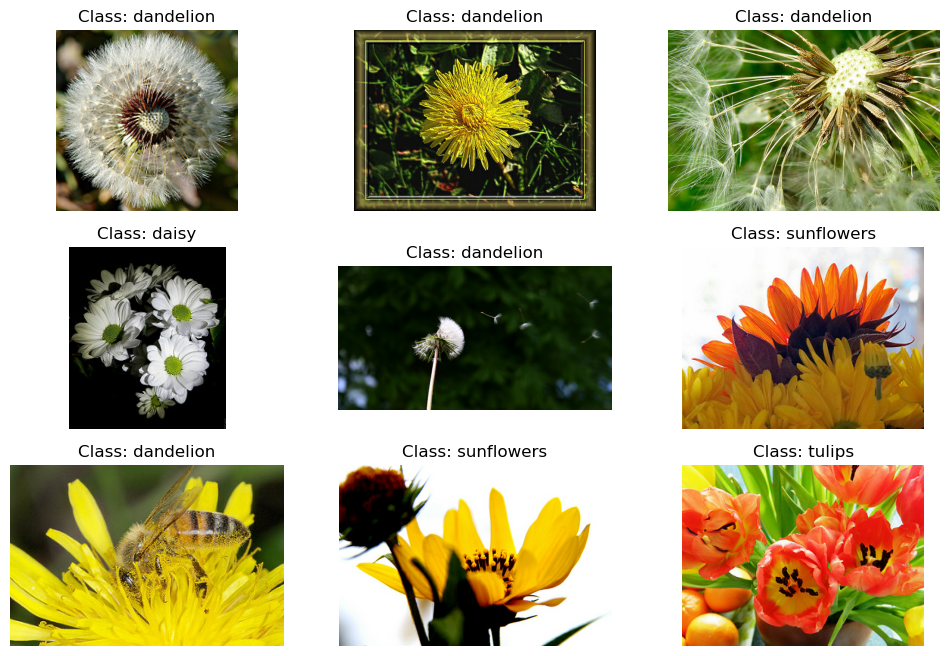

In [5]:
plt.figure(figsize=(12, 8))

index = 0
sample_images = train_set_raw.take(9)

for image, label in sample_images:
    index += 1
    plt.subplot(3, 3, index)
    plt.imshow(image)
    plt.title("Class: {}".format(class_names[label]))
    plt.axis("off")
    
plt.show(block=False)

# Budujemy prostą sieć CNN

## Przygotowanie danych

In [6]:
def preprocess(image, label):
    resized_image = tf.image.resize(image, [224, 224])
    return resized_image, label

In [7]:
batch_size = 32

train_set = train_set_raw.map(preprocess).shuffle(dataset_size).batch(batch_size).prefetch(1)
valid_set = valid_set_raw.map(preprocess).batch(batch_size).prefetch(1)
test_set = test_set_raw.map(preprocess).batch(batch_size).prefetch(1)

<_TakeDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>


2025-06-02 12:17:03.719043: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


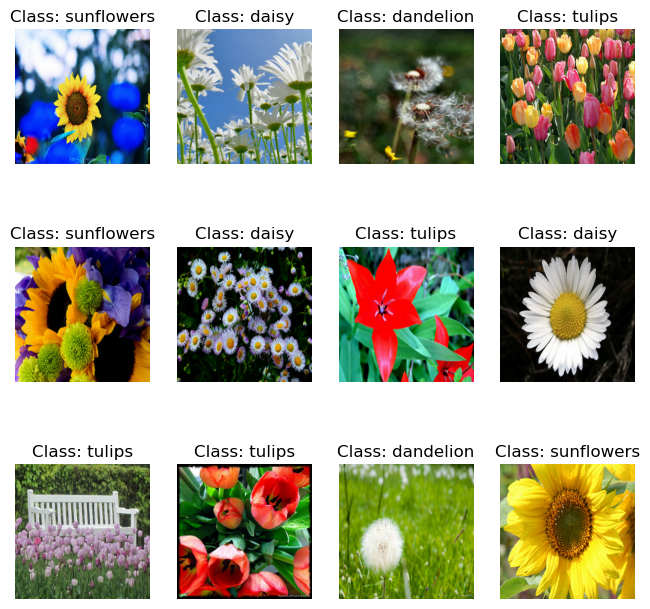

In [8]:
plt.figure(figsize=(8, 8))
sample_batch = train_set.take(1)
print(sample_batch)

for X_batch, y_batch in sample_batch:
    for index in range(12):
        plt.subplot(3, 4, index + 1)
        plt.imshow(X_batch[index]/255.0)
        plt.title("Class: {}".format(class_names[y_batch[index]]))
        plt.axis("off")
        
plt.show()

## Budowa sieci

In [9]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=[224, 224, 3]),
    tf.keras.layers.Rescaling(scale=1./255),

    tf.keras.layers.Conv2D(32, (5, 5), padding='same', kernel_initializer='lecun_normal'),
    tf.keras.layers.Activation('selu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), padding='same', kernel_initializer='lecun_normal'),
    tf.keras.layers.Activation('selu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(128, (3, 3), padding='same', kernel_initializer='lecun_normal'),
    tf.keras.layers.Activation('selu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.GlobalMaxPooling2D(),

    tf.keras.layers.Dense(64, kernel_initializer='lecun_normal'),
    tf.keras.layers.Activation('selu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, kernel_initializer='lecun_normal'),
    tf.keras.layers.Activation('selu'),
    tf.keras.layers.Dropout(0.4),
        
    tf.keras.layers.Dense(n_classes, activation='softmax')
])

In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 107,525 (420.02 KB)

 Trainable params: 107,525 (420.02 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

In [12]:
history = model.fit(
    train_set,
    batch_size=batch_size,
    epochs=10,
    validation_data=valid_set
)

Epoch 1/10


2025-06-02 12:17:04.181894: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


86/86 ━━━━━━━━━━━━━━━━━━━━ 15s 162ms/step - accuracy: 0.3868 - loss: 1.6988 - val_accuracy: 0.6225 - val_loss: 0.9460
Epoch 2/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 15s 174ms/step - accuracy: 0.5591 - loss: 1.1012 - val_accuracy: 0.7042 - val_loss: 0.7587
Epoch 3/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 15s 175ms/step - accuracy: 0.6494 - loss: 0.8874 - val_accuracy: 0.7096 - val_loss: 0.7814
Epoch 4/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 15s 171ms/step - accuracy: 0.6661 - loss: 0.8906 - val_accuracy: 0.7278 - val_loss: 0.7212
Epoch 5/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 15s 170ms/step - accuracy: 0.7076 - loss: 0.7735 - val_accuracy: 0.7278 - val_loss: 0.7524
Epoch 6/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 15s 176ms/step - accuracy: 0.7262 - loss: 0.7193 - val_accuracy: 0.7296 - val_loss: 0.7641
Epoch 7/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 15s 175ms/step - accuracy: 0.7310 - loss: 0.7022 - val_accuracy: 0.7278 - val_loss: 0.7206
Epoch 8/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 15s 172ms/step - accuracy: 0.8108 - loss: 0.5566 - val_accuracy: 0.647

In [13]:
train_loss, train_acc = model.evaluate(train_set)
valid_loss, valid_acc = model.evaluate(valid_set)
test_loss, test_acc = model.evaluate(test_set)

86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.9139 - loss: 0.2636
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7430 - loss: 0.6773
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7379 - loss: 0.6367


In [14]:
acc_tuple = (train_acc, valid_acc, test_acc)

In [15]:
acc_tuple

(0.9178779125213623, 0.7586206793785095, 0.7629427909851074)

In [16]:
import pickle

with open('simple_cnn_acc.pkl', 'wb') as f:
    pickle.dump(acc_tuple, f)

In [17]:
model.save('simple_cnn_flowers.keras')

# Uczenie transferowe

## Przygotowanie danych

In [18]:
def preprocess(image, label):
    resized_image = tf.image.resize(image, [224, 224])
    final_image = tf.keras.applications.xception.preprocess_input(resized_image)
    return final_image, label

In [19]:
train_set = train_set_raw.map(preprocess).shuffle(dataset_size).batch(batch_size).prefetch(1)
valid_set = valid_set_raw.map(preprocess).batch(batch_size).prefetch(1)
test_set = test_set_raw.map(preprocess).batch(batch_size).prefetch(1)

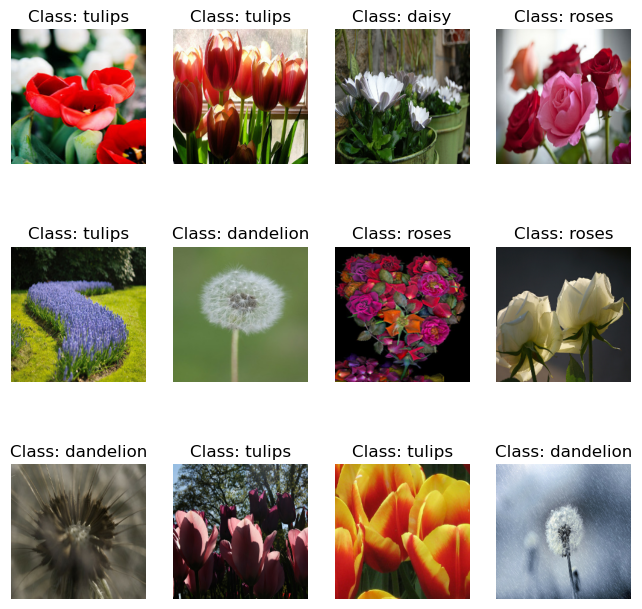

In [20]:
plt.figure(figsize=(8, 8))
sample_batch = train_set.take(1)

for X_batch, y_batch in sample_batch:
    for index in range(12):
        plt.subplot(3, 4, index + 1)
        plt.imshow(X_batch[index] / 2 + 0.5)
        plt.title("Class: {}".format(class_names[y_batch[index]]))
        plt.axis("off")
        
plt.show()

## Budowa sieci

In [21]:
base_model = tf.keras.applications.xception.Xception(
    weights="imagenet",
    include_top=False)

In [23]:
inputs = base_model.input
x = base_model.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)
outputs = tf.keras.layers.Dense(n_classes, activation='softmax')(x)
model = tf.keras.Model(inputs=inputs, outputs=outputs)

In [24]:
for layer in base_model.layers:
    layer.trainable = False

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [25]:
# model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, None,      │        864 │ input_layer_1[0]… │
│ (Conv2D)            │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_bn     │ (None, None,      │        128 │ block1_conv1[0][… │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_act    │ (None, None,      │          0 │ block1_conv1_bn[… │
│ (Activation)        │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, None,      │     18,432 │ block1_conv1_act… │
│ (Conv2D)            │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_bn     │ (None, None,      │        256 │ block1_conv2[0][… │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_act    │ (None, None,      │          0 │ block1_conv2_bn[… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1     │ (None, None,      │      8,768 │ block1_conv2_act… │
│ (SeparableConv2D)   │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1_bn  │ (None, None,      │        512 │ block2_sepconv1[… │
│ (BatchNormalizatio… │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_act │ (None, None,      │          0 │ block2_sepconv1_… │
│ (Activation)        │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2     │ (None, None,      │     17,536 │ block2_sepconv2_… │
│ (SeparableConv2D)   │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_bn  │ (None, None,      │        512 │ block2_sepconv2[… │
│ (BatchNormalizatio… │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, None,      │      8,192 │ block1_conv2_act… │
│                     │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, None,      │          0 │ block2_sepconv2_… │
│ (MaxPooling2D)      │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, None,      │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, None,      │          0 │ block2_pool[0][0… │
│                     │ None, 128)        │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_sepconv1_act │ (None, None,      │          0 │ add[0][0]       

 Total params: 20,871,725 (79.62 MB)

 Trainable params: 10,245 (40.02 KB)

 Non-trainable params: 20,861,480 (79.58 MB)

In [26]:
h1 = model.fit(
    train_set,
    batch_size=batch_size,
    epochs=5,
    validation_data=valid_set
)

Epoch 1/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 17s 176ms/step - accuracy: 0.6565 - loss: 0.9720 - val_accuracy: 0.8131 - val_loss: 0.4985
Epoch 2/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 14s 165ms/step - accuracy: 0.8822 - loss: 0.3765 - val_accuracy: 0.8548 - val_loss: 0.4435
Epoch 3/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 14s 166ms/step - accuracy: 0.9017 - loss: 0.3237 - val_accuracy: 0.8693 - val_loss: 0.4016
Epoch 4/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 15s 171ms/step - accuracy: 0.9248 - loss: 0.2637 - val_accuracy: 0.8730 - val_loss: 0.3827
Epoch 5/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 15s 174ms/step - accuracy: 0.9291 - loss: 0.2398 - val_accuracy: 0.8584 - val_loss: 0.3812


In [27]:
for layer in base_model.layers:
    layer.trainable = True

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [28]:
h2 = model.fit(
    train_set,
    batch_size=batch_size,
    epochs=5,
    validation_data=valid_set
)

Epoch 1/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 70s 680ms/step - accuracy: 0.8353 - loss: 0.5186 - val_accuracy: 0.6951 - val_loss: 3.9845
Epoch 2/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 57s 667ms/step - accuracy: 0.9134 - loss: 0.2787 - val_accuracy: 0.6733 - val_loss: 1.6480
Epoch 3/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 58s 675ms/step - accuracy: 0.9407 - loss: 0.1856 - val_accuracy: 0.8603 - val_loss: 0.5700
Epoch 4/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 59s 683ms/step - accuracy: 0.9612 - loss: 0.1320 - val_accuracy: 0.7949 - val_loss: 0.6445
Epoch 5/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 59s 692ms/step - accuracy: 0.9495 - loss: 0.1368 - val_accuracy: 0.8639 - val_loss: 0.6045


In [29]:
train_loss, train_acc = model.evaluate(train_set)
valid_loss, valid_acc = model.evaluate(valid_set)
test_loss, test_acc = model.evaluate(test_set)

86/86 ━━━━━━━━━━━━━━━━━━━━ 14s 160ms/step - accuracy: 0.9540 - loss: 0.2327
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 153ms/step - accuracy: 0.8676 - loss: 0.6717
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 176ms/step - accuracy: 0.8702 - loss: 0.6503


In [30]:
acc_tuple = (train_acc, valid_acc, test_acc)

In [31]:
acc_tuple

(0.9516715407371521, 0.8638838529586792, 0.8828337788581848)

In [32]:
with open('xception_acc.pkl', 'wb') as f:
    pickle.dump(acc_tuple, f)

In [33]:
model.save('xception_flowers.keras')